In [ ]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# ================================
# 2. LOAD DATASET
# ================================
# Load Boston housing dataset
data = pd.read_csv('1_boston_housing.csv')

# Display first few rows (for understanding dataset)
print(data.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [ ]:
# ================================
# 3. DATA VISUALIZATION (BEFORE TRAINING)
# ================================

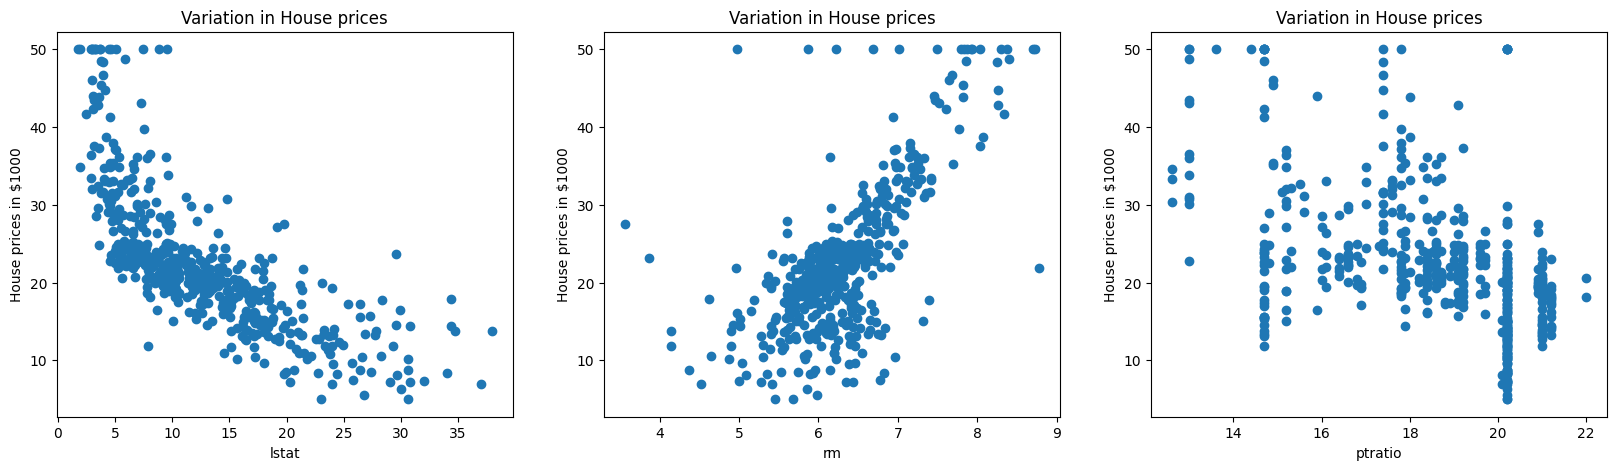

In [ ]:
# --- Scatter Plot ---
# Why: To understand how important features affect price
plt.figure(figsize=(20,5))

features = ['lstat','rm','ptratio']  # important features
for i, col in enumerate(features):
    plt.subplot(1, len(features), i+1)
    x = data[col]
    y = data['MEDV']
    plt.scatter(x, y, marker='o')
    plt.title("Variation in House prices")
    plt.xlabel(col)
    plt.ylabel("House prices in $1000")

plt.show()

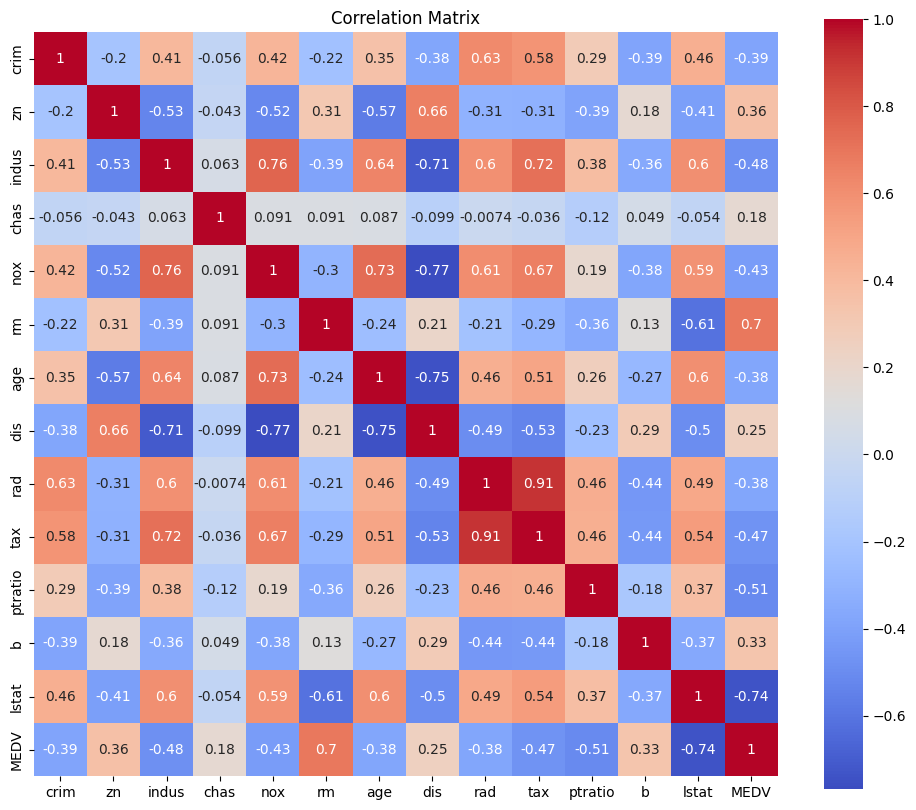

In [ ]:
# --- Correlation Heatmap ---
# Why: To find relationships between features
correlation = data.corr()

plt.figure(figsize=(12,10))
sns.heatmap(correlation, square=True, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

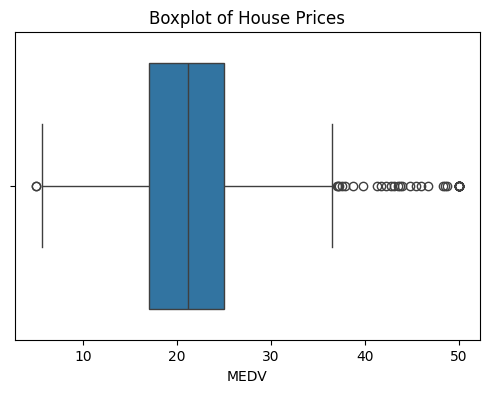

In [ ]:
# --- Boxplot ---
# Why: To detect outliers in price
plt.figure(figsize=(6,4))
sns.boxplot(x=data['MEDV'])
plt.title("Boxplot of House Prices")
plt.show()

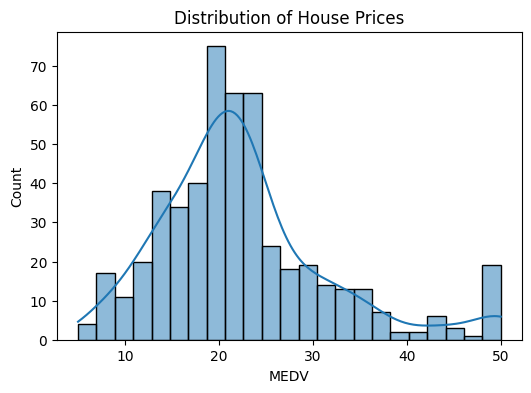

In [ ]:
# --- Distribution Plot ---
# Why: To check if data is normally distributed
plt.figure(figsize=(6,4))
sns.histplot(data['MEDV'], kde=True)
plt.title("Distribution of House Prices")
plt.show()

In [ ]:
# ================================
# 4. DATA PREPROCESSING
# ================================

# Split features and target
X = data.iloc[:, :-1].values  # input features
y = data.iloc[:, -1].values   # target (price)

# Normalize features (important for faster convergence)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
# ================================
# 5. MODEL ARCHITECTURE
# ================================

# Create Deep Neural Network
model = Sequential()

# Input + Hidden layers
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))

# Output layer (1 neuron for regression)
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile model
model.compile(
    optimizer='adam',  # efficient optimizer
    loss='mse',        # minimize squared error
    metrics=['mae']    # track MAE
)

In [ ]:
# ================================
# 6. MODEL TRAINING
# ================================

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 559.6943 - mae: 21.6863 - val_loss: 504.5784 - val_mae: 20.8422
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 442.5543 - mae: 18.8537 - val_loss: 343.9496 - val_mae: 16.7517
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 236.9675 - mae: 12.9137 - val_loss: 111.9430 - val_mae: 8.4468
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 71.4622 - mae: 6.5199 - val_loss: 46.1768 - val_mae: 4.7040
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 43.3006 - mae: 5.1538 - val_loss: 38.4389 - val_mae: 4.1569
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 29.8044 - mae: 4.0343 - val_loss: 37.0331 - val_mae: 4.0276
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 24.5488 - mae: 3.6825 - val_loss: 37.0761 - val_mae: 4.0036
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 22.1614 - mae: 3.4613 - val_loss: 37.0152 - val_mae: 3.9997
Epoch 9/100
23/23 ━━━━━━━━━━━━

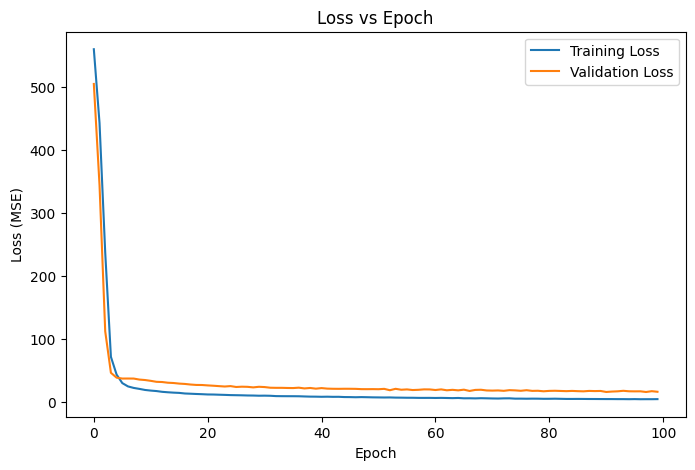

In [ ]:
# ================================
# 7. GRAPH: LOSS vs EPOCH
# ================================
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

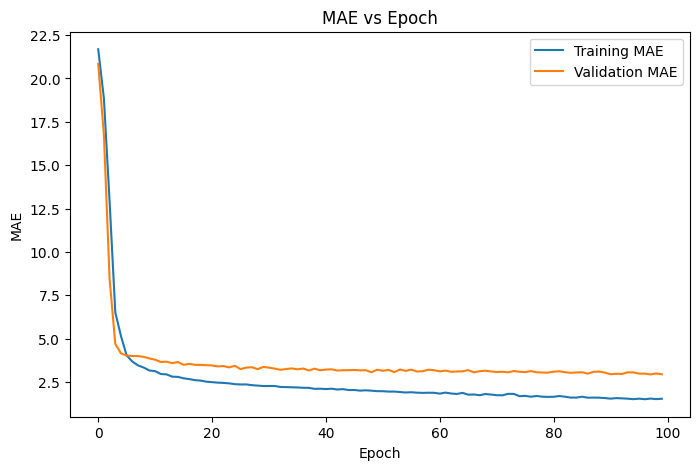

In [ ]:
# ================================
# 8. GRAPH: MAE vs EPOCH
# ================================
plt.figure(figsize=(8,5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title("MAE vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

In [ ]:
# ================================
# 9. MODEL EVALUATION
# ================================

# Predict on test data
y_pred = model.predict(X_test)

# Calculate errors
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R2 Score:", r2)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

Model Performance:
Mean Squared Error (MSE): 10.56881520782635
Mean Absolute Error (MAE): 2.1674619123047476
R2 Score: 0.8558806766491138


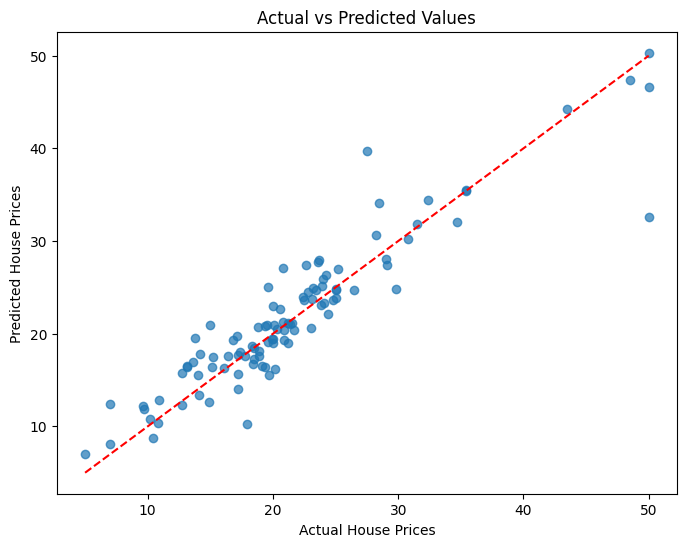

In [ ]:
# ================================
# 10. GRAPH: ACTUAL vs PREDICTED
# ================================

# Why: To visually compare model predictions with actual values

plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(y_test, y_pred, alpha=0.7)

# Reference line (Perfect prediction line)
# If model is perfect, all points should lie on this line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title("Actual vs Predicted Values")
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")

plt.show()

In [ ]:
# ================================
# 11. USER INPUT PREDICTION
# ================================

print("\nEnter values for prediction:")

user_input = []
for col in data.columns[:-1]:
    val = float(input(f"Enter value for {col}: "))
    user_input.append(val)

# Convert to numpy array
user_input = np.array(user_input).reshape(1, -1)

# Normalize using same scaler
user_input_scaled = scaler.transform(user_input)

# Predict
prediction = model.predict(user_input_scaled)

print("\nPredicted House Price:", prediction[0][0])


Enter values for prediction:
Enter value for crim: 43
Enter value for zn: 53
Enter value for indus: 12
Enter value for chas: 87
Enter value for nox: 23
Enter value for rm: 01
Enter value for age: 3
Enter value for dis: 7
Enter value for rad: 75
Enter value for tax: 23
Enter value for ptratio: 98
Enter value for b: 5
Enter value for lstat: 23
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

Predicted House Price: 317.06375
